# Self-Pruning Case Study

In [1]:
# Standard library imports for file handling, math, randomness, and timing.
import copy
import math
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

# Configuring all the required parameters
CONFIG = {
    "seed": 42,
    "data_root": "./data",
    "output_dir": "./outputs_case_study_corrected",
    "batch_size": 128,
    "epochs": 30,
    "warmup_epochs": 5,
    "learning_rate": 1e-3,
    "weight_decay": 1e-4,
    "gate_lr_multiplier": 5.0,
    "hidden_sizes": [512, 256, 128],
    "dropout": 0.25,
    "lambda_values": [1e-4, 3e-4, 1e-3, 3e-3],
    "prune_threshold": 0.10,
    "num_workers": 2 if __import__("os").name != "nt" else 0,
    "num_classes": 10,
    "input_dim": 3 * 32 * 32,
}

Path(CONFIG["output_dir"]).mkdir(parents=True, exist_ok=True)


def set_seed(seed: int) -> None:
   # Seed all major random number generators for repeatable experiments.
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)



# Initialize the runtime once before data loading and model creation.
set_seed(CONFIG["seed"])
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)
print("Hidden sizes:", CONFIG["hidden_sizes"])
print("Lambda values:", CONFIG["lambda_values"])
print("Neuron prune threshold:", CONFIG["prune_threshold"])

Device: cuda
Hidden sizes: [512, 256, 128]
Lambda values: [0.0001, 0.0003, 0.001, 0.003]
Neuron prune threshold: 0.1


## Data


In [2]:
# Light augmentation is used for training to improve generalization.
train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])
# Test data uses only normalization because evaluation should be deterministic.
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

train_dataset = torchvision.datasets.CIFAR10(
    root=CONFIG["data_root"],
    train=True,
    download=True,
    transform=train_transform,
)

test_dataset = torchvision.datasets.CIFAR10(
    root=CONFIG["data_root"],
    train=False,
    download=True,
    transform=test_transform,
)
# DataLoader settings keep training shuffled and evaluation stable.
train_loader = DataLoader(
    train_dataset,
    batch_size=CONFIG["batch_size"],
    shuffle=True,
    num_workers=CONFIG["num_workers"],
    pin_memory=torch.cuda.is_available(),
)

test_loader = DataLoader(
    test_dataset,
    batch_size=CONFIG["batch_size"],
    shuffle=False,
    num_workers=CONFIG["num_workers"],
    pin_memory=torch.cuda.is_available(),
)

print("Train size:", len(train_dataset))
print("Test size :", len(test_dataset))

100%|██████████| 170M/170M [00:03<00:00, 49.0MB/s]


Train size: 50000
Test size : 10000


## Model Design


Instead of assigning one gate to every weight, we assign one gate to every **hidden neuron**.
That makes the pruning **structured**:

- if a neuron's gate falls below threshold, the whole hidden unit is pruned
- neuron counts become meaningful
- the compacted network physically becomes smaller

In [3]:
class NeuronGate(nn.Module):
    #One learnable sigmoid gate per hidden neuron.

    def __init__(self, num_neurons: int, init_logit: float = 0.0):
        super().__init__()
        # init_logit=0 means sigmoid(logit)=0.5, which makes pruning easier than starting near 0.88.
        self.logits = nn.Parameter(torch.full((num_neurons,), init_logit))

    def gate_values(self) -> torch.Tensor:
      # Convert unconstrained logits into soft gates in the range [0, 1].
        return torch.sigmoid(self.logits)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
      # Broadcast one gate value across the whole batch for each hidden neuron.
        gates = self.gate_values().view(1, -1)
        return x * gates

    def hard_mask(self, threshold: float) -> torch.Tensor:
        return (self.gate_values() >= threshold)


class StructuredSelfPruningNet(nn.Module):
    """MLP whose hidden units are pruned by neuron-level gates."""

    def __init__(self, input_dim: int, hidden_sizes: list[int], num_classes: int, dropout: float):
        super().__init__()
        h1, h2, h3 = hidden_sizes
        # Standard MLP backbone; the structured pruning comes from the gate modules below.
        self.fc1 = nn.Linear(input_dim, h1)
        self.fc2 = nn.Linear(h1, h2)
        self.fc3 = nn.Linear(h2, h3)
        self.fc_out = nn.Linear(h3, num_classes)

        # Each gate module controls whether a hidden neuron stays active.
        self.g1 = NeuronGate(h1)
        self.g2 = NeuronGate(h2)
        self.g3 = NeuronGate(h3)

        self.dropout = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = x.view(x.size(0), -1)
        x = self.dropout(self.g1(F.relu(self.fc1(x))))
        x = self.dropout(self.g2(F.relu(self.fc2(x))))
        x = self.dropout(self.g3(F.relu(self.fc3(x))))
        return self.fc_out(x)

    def gate_modules(self):
        return [self.g1, self.g2, self.g3]

    def all_gate_values(self) -> torch.Tensor:
        return torch.cat([gate.gate_values() for gate in self.gate_modules()])

    def sparsity_loss(self) -> torch.Tensor:
        # L1-style penalty on positive sigmoid gates.
        return self.all_gate_values().sum()

    def neuron_sparsity(self, threshold: float) -> float:
        gates = self.all_gate_values()
        return 100.0 * (gates < threshold).float().mean().item()

    def active_neuron_summary(self, threshold: float) -> dict:
      # Summarize how many hidden neurons survive hard thresholding.
        counts_before = [self.fc1.out_features, self.fc2.out_features, self.fc3.out_features]
        counts_after = [int(g.hard_mask(threshold).sum().item()) for g in self.gate_modules()]
        return {
            "before_per_layer": counts_before,
            "after_per_layer": counts_after,
            "total_before": int(sum(counts_before)),
            "total_after": int(sum(counts_after)),
        }


class CompactMLP(nn.Module):
    """Physically compact network built after hard pruning."""

    def __init__(self, input_dim: int, hidden_sizes: list[int], num_classes: int):
        super().__init__()
        h1, h2, h3 = hidden_sizes
        self.fc1 = nn.Linear(input_dim, h1)
        self.fc2 = nn.Linear(h1, h2)
        self.fc3 = nn.Linear(h2, h3)
        self.fc_out = nn.Linear(h3, num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))
        return self.fc_out(x)


probe_model = StructuredSelfPruningNet(
    input_dim=CONFIG["input_dim"],
    hidden_sizes=CONFIG["hidden_sizes"],
    num_classes=CONFIG["num_classes"],
    dropout=CONFIG["dropout"],
)

print("Model ready.")
print("Initial mean gate:", round(probe_model.all_gate_values().mean().item(), 4))
print("Initial active neuron summary:", probe_model.active_neuron_summary(CONFIG["prune_threshold"]))

Model ready.
Initial mean gate: 0.5
Initial active neuron summary: {'before_per_layer': [512, 256, 128], 'after_per_layer': [512, 256, 128], 'total_before': 896, 'total_after': 896}


## Training Utilities

We use:

`total_loss = classification_loss + lambda * sparsity_loss`

Two practical improvements are added:

- a higher learning rate for the gate logits
- lambda warmup during the first few epochs

In [4]:
@torch.no_grad()
def evaluate_accuracy(model: nn.Module, loader: DataLoader) -> float:
   # Evaluation is isolated from gradient tracking for speed and memory savings.
    model.eval()
    correct = 0
    total = 0
    for images, labels in loader:
        images = images.to(device, non_blocking=(device.type == "cuda"))
        labels = labels.to(device, non_blocking=(device.type == "cuda"))
        logits = model(images)
        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    return 100.0 * correct / total


def lambda_for_epoch(target_lambda: float, epoch: int, warmup_epochs: int) -> float:
    scale = min(1.0, epoch / max(1, warmup_epochs))
    return target_lambda * scale


def train_one_epoch(
    model: StructuredSelfPruningNet,
    loader: DataLoader,
    optimizer: torch.optim.Optimizer,
    target_lambda: float,
    epoch: int,
) -> dict:
    model.train()
    criterion = nn.CrossEntropyLoss()

    total_loss_sum = 0.0
    cls_loss_sum = 0.0
    reg_loss_sum = 0.0
    correct = 0
    total = 0

    current_lambda = lambda_for_epoch(target_lambda, epoch, CONFIG["warmup_epochs"])

    for images, labels in loader:
        images = images.to(device, non_blocking=(device.type == "cuda"))
        labels = labels.to(device, non_blocking=(device.type == "cuda"))

        optimizer.zero_grad(set_to_none=True)
        logits = model(images)

        cls_loss = criterion(logits, labels)
        reg_loss = model.sparsity_loss()
        loss = cls_loss + current_lambda * reg_loss

        loss.backward()
        optimizer.step()

        total_loss_sum += loss.item()
        cls_loss_sum += cls_loss.item()
        reg_loss_sum += reg_loss.item()

        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return {
        "lambda_used": current_lambda,
        "loss": total_loss_sum / len(loader),
        "cls_loss": cls_loss_sum / len(loader),
        "reg_loss": reg_loss_sum / len(loader),
        "train_acc": 100.0 * correct / total,
    }


@torch.no_grad()
def safe_mask(gate: NeuronGate, threshold: float) -> torch.Tensor:
    mask = gate.hard_mask(threshold)
    if mask.sum().item() == 0:
        # Keep at least one neuron so the compact model stays valid.
        best_index = gate.gate_values().argmax().item()
        mask[best_index] = True
    return mask


@torch.no_grad()
def build_compact_model(model: StructuredSelfPruningNet, threshold: float) -> CompactMLP:
   # Convert the soft-gated network into a physically smaller dense model.
    model_cpu = copy.deepcopy(model).cpu().eval()

    # Build boolean masks that tell us which hidden units survive pruning.
    m1 = safe_mask(model_cpu.g1, threshold)
    m2 = safe_mask(model_cpu.g2, threshold)
    m3 = safe_mask(model_cpu.g3, threshold)

    g1 = model_cpu.g1.gate_values()[m1]
    g2 = model_cpu.g2.gate_values()[m2]
    g3 = model_cpu.g3.gate_values()[m3]

    compact = CompactMLP(
        input_dim=model_cpu.fc1.in_features,
        hidden_sizes=[int(m1.sum().item()), int(m2.sum().item()), int(m3.sum().item())],
        num_classes=model_cpu.fc_out.out_features,
    )

    # Layer 1 keeps only the surviving hidden neurons.
    compact.fc1.weight.copy_(model_cpu.fc1.weight[m1, :])
    compact.fc1.bias.copy_(model_cpu.fc1.bias[m1])

    # The gate after layer 1 scales activations that become inputs to layer 2.
    fc2_weight = model_cpu.fc2.weight[m2][:, m1].clone()
    fc2_weight *= g1.view(1, -1)
    compact.fc2.weight.copy_(fc2_weight)
    compact.fc2.bias.copy_(model_cpu.fc2.bias[m2])

    # The gate after layer 2 scales activations that become inputs to layer 3.
    fc3_weight = model_cpu.fc3.weight[m3][:, m2].clone()
    fc3_weight *= g2.view(1, -1)
    compact.fc3.weight.copy_(fc3_weight)
    compact.fc3.bias.copy_(model_cpu.fc3.bias[m3])

    # The gate after layer 3 scales inputs to the output layer.
    out_weight = model_cpu.fc_out.weight[:, m3].clone()
    out_weight *= g3.view(1, -1)
    compact.fc_out.weight.copy_(out_weight)
    compact.fc_out.bias.copy_(model_cpu.fc_out.bias)

    return compact


print("Training and pruning utilities are ready.")

Training and pruning utilities are ready.


## Main Experiment

We train one model per lambda and report:

- test accuracy
- neuron sparsity
- hidden neurons before pruning
- hidden neurons after pruning
- compact model size

In [5]:
all_history = {}
final_results = []
trained_models = {}
# Train one separate model for each lambda to study the trade-off curve.
for lam in CONFIG["lambda_values"]:
    print("\n" + "=" * 90)
    print(f"Training structured pruning model for lambda = {lam}")
    print("=" * 90)

    model = StructuredSelfPruningNet(
        input_dim=CONFIG["input_dim"],
        hidden_sizes=CONFIG["hidden_sizes"],
        num_classes=CONFIG["num_classes"],
        dropout=CONFIG["dropout"],
    ).to(device)

# Separate gate parameters so they can learn faster than the backbone weights.
    gate_params = []
    main_params = []
    for name, param in model.named_parameters():
        if "logits" in name:
            gate_params.append(param)
        else:
            main_params.append(param)

    optimizer = torch.optim.Adam([
        {
            "params": main_params,
            "lr": CONFIG["learning_rate"],
            "weight_decay": CONFIG["weight_decay"],
        },
        {
            "params": gate_params,
            "lr": CONFIG["learning_rate"] * CONFIG["gate_lr_multiplier"],
            "weight_decay": 0.0,
        },
    ])

    history = {
        "train_acc": [],
        "test_acc": [],
        "loss": [],
        "cls_loss": [],
        "reg_loss": [],
        "neuron_sparsity": [],
        "gate_mean": [],
        "lambda_used": [],
    }

 # Track both accuracy and sparsity as the model trains.
    for epoch in range(1, CONFIG["epochs"] + 1):
        train_stats = train_one_epoch(model, train_loader, optimizer, lam, epoch)
        test_acc = evaluate_accuracy(model, test_loader)
        gate_values = model.all_gate_values().detach().cpu()

        history["train_acc"].append(train_stats["train_acc"])
        history["test_acc"].append(test_acc)
        history["loss"].append(train_stats["loss"])
        history["cls_loss"].append(train_stats["cls_loss"])
        history["reg_loss"].append(train_stats["reg_loss"])
        history["neuron_sparsity"].append(model.neuron_sparsity(CONFIG["prune_threshold"]))
        history["gate_mean"].append(gate_values.mean().item())
        history["lambda_used"].append(train_stats["lambda_used"])

        print(
            f"Epoch {epoch:02d}/{CONFIG['epochs']} | "
            f"lambda_used={train_stats['lambda_used']:.6f} | "
            f"loss={train_stats['loss']:.4f} | "
            f"train_acc={train_stats['train_acc']:.2f}% | "
            f"test_acc={test_acc:.2f}% | "
            f"neuron_sparsity={history['neuron_sparsity'][-1]:.2f}% | "
            f"gate_mean={history['gate_mean'][-1]:.4f}"
        )

    compact_model = build_compact_model(model, CONFIG["prune_threshold"]).to(device)
    compact_test_acc = evaluate_accuracy(compact_model, test_loader)
    summary = model.active_neuron_summary(CONFIG["prune_threshold"])

# After training, build a hard-pruned compact model and evaluate it separately.
    result = {
        "lambda": lam,
        "soft_model_test_accuracy": round(history["test_acc"][-1], 2),
        "compact_model_test_accuracy": round(compact_test_acc, 2),
        "neuron_sparsity_pct": round(model.neuron_sparsity(CONFIG["prune_threshold"]), 2),
        "neurons_before": summary["total_before"],
        "neurons_after": summary["total_after"],
        "before_per_layer": summary["before_per_layer"],
        "after_per_layer": summary["after_per_layer"],
        "compact_hidden_sizes": [
            compact_model.fc1.out_features,
            compact_model.fc2.out_features,
            compact_model.fc3.out_features,
        ],
    }

    final_results.append(result)
    all_history[lam] = history
    trained_models[lam] = copy.deepcopy(model).cpu()

final_results = sorted(final_results, key=lambda row: row["lambda"])
final_results


Training structured pruning model for lambda = 0.0001
Epoch 01/30 | lambda_used=0.000020 | loss=1.9019 | train_acc=31.05% | test_acc=38.74% | neuron_sparsity=0.00% | gate_mean=0.4824
Epoch 02/30 | lambda_used=0.000040 | loss=1.7626 | train_acc=37.24% | test_acc=41.97% | neuron_sparsity=1.45% | gate_mean=0.4630
Epoch 03/30 | lambda_used=0.000060 | loss=1.7028 | train_acc=39.62% | test_acc=42.35% | neuron_sparsity=1.90% | gate_mean=0.4443
Epoch 04/30 | lambda_used=0.000080 | loss=1.6710 | train_acc=41.27% | test_acc=44.73% | neuron_sparsity=2.90% | gate_mean=0.4257
Epoch 05/30 | lambda_used=0.000100 | loss=1.6513 | train_acc=42.16% | test_acc=44.98% | neuron_sparsity=3.46% | gate_mean=0.4081
Epoch 06/30 | lambda_used=0.000100 | loss=1.6318 | train_acc=42.85% | test_acc=46.12% | neuron_sparsity=4.35% | gate_mean=0.3934
Epoch 07/30 | lambda_used=0.000100 | loss=1.6134 | train_acc=43.14% | test_acc=46.69% | neuron_sparsity=4.58% | gate_mean=0.3801
Epoch 08/30 | lambda_used=0.000100 | loss=

[{'lambda': 0.0001,
  'soft_model_test_accuracy': 51.44,
  'compact_model_test_accuracy': 51.58,
  'neuron_sparsity_pct': 19.98,
  'neurons_before': 896,
  'neurons_after': 717,
  'before_per_layer': [512, 256, 128],
  'after_per_layer': [373, 222, 122],
  'compact_hidden_sizes': [373, 222, 122]},
 {'lambda': 0.0003,
  'soft_model_test_accuracy': 50.97,
  'compact_model_test_accuracy': 50.99,
  'neuron_sparsity_pct': 31.25,
  'neurons_before': 896,
  'neurons_after': 616,
  'before_per_layer': [512, 256, 128],
  'after_per_layer': [278, 220, 118],
  'compact_hidden_sizes': [278, 220, 118]},
 {'lambda': 0.001,
  'soft_model_test_accuracy': 52.18,
  'compact_model_test_accuracy': 37.88,
  'neuron_sparsity_pct': 57.59,
  'neurons_before': 896,
  'neurons_after': 380,
  'before_per_layer': [512, 256, 128],
  'after_per_layer': [117, 141, 122],
  'compact_hidden_sizes': [117, 141, 122]},
 {'lambda': 0.003,
  'soft_model_test_accuracy': 49.16,
  'compact_model_test_accuracy': 13.84,
  'neuro

## Results Table

This is the key table for the case study.

In [6]:
# Format the final lambda comparison as a plain-text table for the report.
headers = [
    "Lambda",
    "Soft Test Acc",
    "Compact Test Acc",
    "Neuron Sparsity %",
    "Neurons Before",
    "Neurons After",
    "Compact Hidden Sizes",
]

rows = []
for row in final_results:
    rows.append([
        f"{row['lambda']:.4g}",
        f"{row['soft_model_test_accuracy']:.2f}",
        f"{row['compact_model_test_accuracy']:.2f}",
        f"{row['neuron_sparsity_pct']:.2f}",
        row["neurons_before"],
        row["neurons_after"],
        str(row["compact_hidden_sizes"]),
    ])

col_widths = [max(len(str(item)) for item in [header] + [r[i] for r in rows]) for i, header in enumerate(headers)]

def format_row(items):
    return " | ".join(str(item).ljust(col_widths[i]) for i, item in enumerate(items))

print(format_row(headers))
print("-+-".join("-" * width for width in col_widths))
for row in rows:
    print(format_row(row))

# Pick the best result by compact-model accuracy, then break ties with sparsity.
best_tradeoff = max(
    final_results,
    key=lambda row: (row["compact_model_test_accuracy"], row["neuron_sparsity_pct"])
)

print("\nBest result based on compact-model accuracy, then sparsity:")
print(best_tradeoff)

Lambda | Soft Test Acc | Compact Test Acc | Neuron Sparsity % | Neurons Before | Neurons After | Compact Hidden Sizes
-------+---------------+------------------+-------------------+----------------+---------------+---------------------
0.0001 | 51.44         | 51.58            | 19.98             | 896            | 717           | [373, 222, 122]     
0.0003 | 50.97         | 50.99            | 31.25             | 896            | 616           | [278, 220, 118]     
0.001  | 52.18         | 37.88            | 57.59             | 896            | 380           | [117, 141, 122]     
0.003  | 49.16         | 13.84            | 84.82             | 896            | 136           | [7, 41, 88]         

Best result based on compact-model accuracy, then sparsity:
{'lambda': 0.0001, 'soft_model_test_accuracy': 51.44, 'compact_model_test_accuracy': 51.58, 'neuron_sparsity_pct': 19.98, 'neurons_before': 896, 'neurons_after': 717, 'before_per_layer': [512, 256, 128], 'after_per_layer': [373, 22

## Learning Curves

These plots help verify whether pruning is actually happening through training.

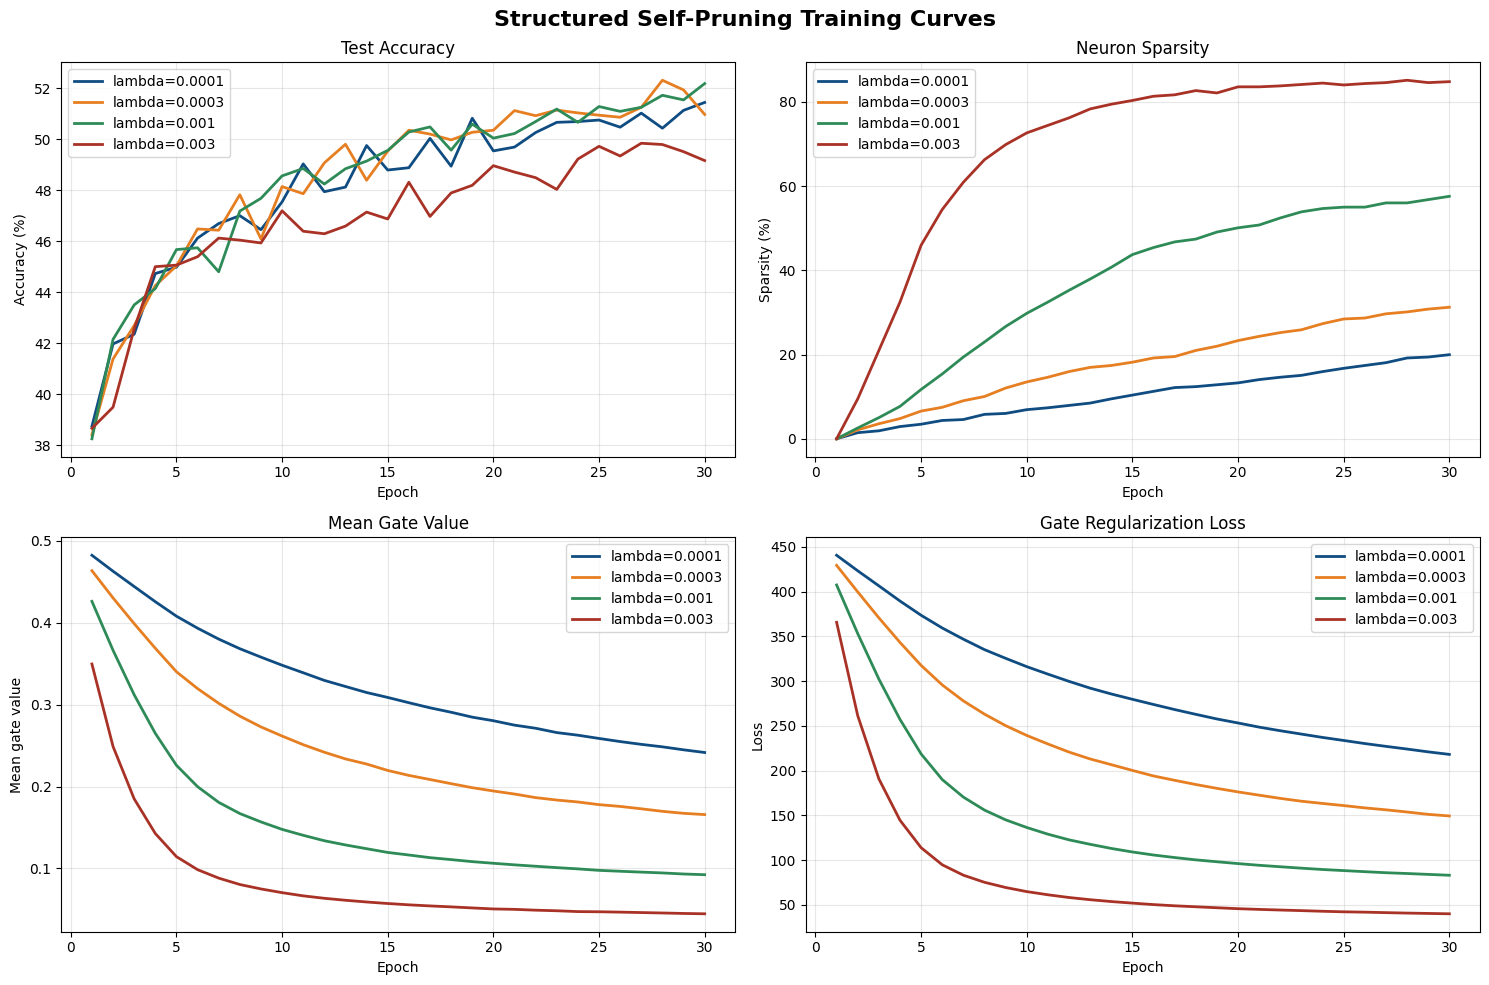

In [7]:
# Plot how each lambda changes accuracy, sparsity, gate magnitude, and regularization loss.
colors = ["#0F4C81", "#E67E22", "#2E8B57", "#A93226"]
epochs = range(1, CONFIG["epochs"] + 1)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle("Structured Self-Pruning Training Curves", fontsize=16, fontweight="bold")

for (lam, history), color in zip(all_history.items(), colors):
    axes[0, 0].plot(epochs, history["test_acc"], color=color, linewidth=2, label=f"lambda={lam}")
    axes[0, 1].plot(epochs, history["neuron_sparsity"], color=color, linewidth=2, label=f"lambda={lam}")
    axes[1, 0].plot(epochs, history["gate_mean"], color=color, linewidth=2, label=f"lambda={lam}")
    axes[1, 1].plot(epochs, history["reg_loss"], color=color, linewidth=2, label=f"lambda={lam}")

axes[0, 0].set_title("Test Accuracy")
axes[0, 1].set_title("Neuron Sparsity")
axes[1, 0].set_title("Mean Gate Value")
axes[1, 1].set_title("Gate Regularization Loss")

for ax in axes.ravel():
    ax.set_xlabel("Epoch")
    ax.grid(alpha=0.3)
    ax.legend()

axes[0, 0].set_ylabel("Accuracy (%)")
axes[0, 1].set_ylabel("Sparsity (%)")
axes[1, 0].set_ylabel("Mean gate value")
axes[1, 1].set_ylabel("Loss")

plt.tight_layout()
plt.show()

## Gate Distribution Of The Best Model

If pruning is working, many gates should move close to zero.

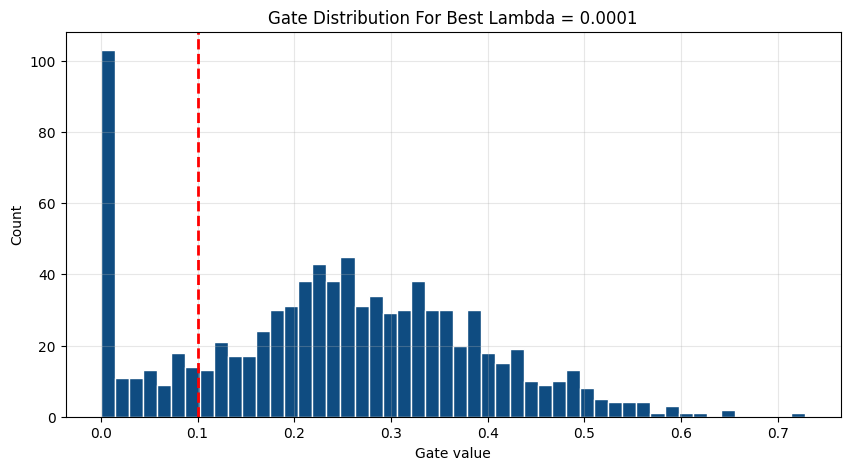

Mean gate value: 0.2416
Fraction below threshold: 19.98 %


In [9]:
# Inspect the final gate distribution for the best overall trade-off.
best_lambda = best_tradeoff["lambda"]
best_model = trained_models[best_lambda]
best_gates = best_model.all_gate_values().detach().numpy()

plt.figure(figsize=(10, 5))
plt.hist(best_gates, bins=50, color="#0F4C81", edgecolor="white")
plt.axvline(CONFIG["prune_threshold"], color="red", linestyle="--", linewidth=2)
plt.title(f"Gate Distribution For Best Lambda = {best_lambda}")
plt.xlabel("Gate value")
plt.ylabel("Count")
plt.grid(alpha=0.3)
plt.show()

print("Mean gate value:", round(best_gates.mean(), 4))
print("Fraction below threshold:", round((best_gates < CONFIG["prune_threshold"]).mean() * 100, 2), "%")

## Hard Pruning Example

This cell proves that the pruned model is actually **smaller**, not just softly suppressed.

In [10]:
# Show a concrete before/after pruning example for the selected best model.
best_model_gpu = copy.deepcopy(best_model).to(device)
compact_best_model = build_compact_model(best_model_gpu, CONFIG["prune_threshold"]).to(device)

before_summary = best_model.active_neuron_summary(CONFIG["prune_threshold"])
soft_acc = evaluate_accuracy(best_model_gpu, test_loader)
compact_acc = evaluate_accuracy(compact_best_model, test_loader)

print("Before pruning:")
print("Total hidden neurons:", before_summary["total_before"])
print("Per-layer hidden sizes:", before_summary["before_per_layer"])
print(f"Soft model test accuracy: {soft_acc:.2f}%")

print("\nAfter hard structured pruning:")
print("Total hidden neurons:", before_summary["total_after"])
print("Per-layer hidden sizes:", before_summary["after_per_layer"])
print(
    "Compact architecture:",
    [compact_best_model.fc1.out_features, compact_best_model.fc2.out_features, compact_best_model.fc3.out_features]
)
print(f"Compact model test accuracy: {compact_acc:.2f}%")

Before pruning:
Total hidden neurons: 896
Per-layer hidden sizes: [512, 256, 128]
Soft model test accuracy: 51.44%

After hard structured pruning:
Total hidden neurons: 717
Per-layer hidden sizes: [373, 222, 122]
Compact architecture: [373, 222, 122]
Compact model test accuracy: 51.58%
